In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("customer_churn_dataset.csv")

# Display first 5 rows
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,SatisfactionScore,Churn
0,CUST0001,Male,0,Yes,No,29,Yes,DSL,Yes,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,63.87,1865.09,1,Yes
1,CUST0002,Female,1,No,No,35,Yes,DSL,Yes,No,...,Yes,No,No,Two year,No,Mailed check,59.11,2076.65,3,No
2,CUST0003,Male,0,No,No,66,Yes,Fiber optic,No,No,...,Yes,Yes,No,One year,Yes,Electronic check,78.47,5188.59,5,No
3,CUST0004,Male,0,No,No,48,Yes,Fiber optic,No,Yes,...,No,Yes,No,Month-to-month,Yes,Electronic check,86.22,4139.23,3,No
4,CUST0005,Male,0,No,Yes,54,Yes,No,No service,No service,...,No service,No service,No service,One year,Yes,Bank transfer,18.25,993.17,1,No


In [2]:
# Dataset Shape
print("Dataset Shape:")
print(df.shape)

print("\n" + "="*60)

# Dataset Information
print("Dataset Information:")
df.info()

print("\n" + "="*60)

# Column Names
print("Column Names:")
print(df.columns.tolist())

Dataset Shape:
(1500, 21)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1500 non-null   object 
 1   Gender             1500 non-null   object 
 2   SeniorCitizen      1500 non-null   int64  
 3   Partner            1500 non-null   object 
 4   Dependents         1500 non-null   object 
 5   Tenure             1500 non-null   int64  
 6   PhoneService       1500 non-null   object 
 7   InternetService    1500 non-null   object 
 8   OnlineSecurity     1500 non-null   object 
 9   OnlineBackup       1500 non-null   object 
 10  DeviceProtection   1500 non-null   object 
 11  TechSupport        1500 non-null   object 
 12  StreamingTV        1500 non-null   object 
 13  StreamingMovies    1500 non-null   object 
 14  Contract           1500 non-null   object 
 15  PaperlessBilling   1500 

In [3]:
# Step 3: Check Missing Values

print("Missing Values in Each Column")
print("--------------------------------")

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())


# Check duplicate rows
print("\n" + "="*60)
print("Duplicate Records")
print("--------------------------------")

duplicate_count = df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_count)

Missing Values in Each Column
--------------------------------
CustomerID           0
Gender               0
SeniorCitizen        0
Partner              0
Dependents           0
Tenure               0
PhoneService         0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
SatisfactionScore    0
Churn                0
dtype: int64

Total Missing Values: 0

Duplicate Records
--------------------------------
Total Duplicate Rows: 0


In [4]:
# Step 4: Statistical Summary

print("Statistical Summary of Numerical Features")
print("------------------------------------------")

df.describe()

Statistical Summary of Numerical Features
------------------------------------------


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,SatisfactionScore
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.162667,36.092000,61.433587,2205.405247,2.987333
std,0.369184,21.101447,23.791071,1616.229334,1.435460
min,0.000000,0.000000,18.250000,0.920000,1.000000
25%,0.000000,18.000000,47.180000,844.357500,2.000000
50%,0.000000,36.000000,65.275000,1795.750000,3.000000
75%,0.000000,54.000000,80.232500,3416.197500,4.000000
max,1.000000,72.000000,114.640000,6623.510000,5.000000


In [5]:
# Step 5: Check Unique Values in Categorical Columns

categorical_cols = [
    "Gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print("Number of unique values:", df[col].nunique())


# Target Variable Distribution
print("\n" + "="*60)
print("Churn Distribution")
print("--------------------------------")

print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)


--- Gender ---
Gender
Male      753
Female    747
Name: count, dtype: int64
Number of unique values: 2

--- Partner ---
Partner
No     773
Yes    727
Name: count, dtype: int64
Number of unique values: 2

--- Dependents ---
Dependents
No     1054
Yes     446
Name: count, dtype: int64
Number of unique values: 2

--- PhoneService ---
PhoneService
Yes    1358
No      142
Name: count, dtype: int64
Number of unique values: 2

--- InternetService ---
InternetService
Fiber optic    680
DSL            529
No             291
Name: count, dtype: int64
Number of unique values: 3

--- OnlineSecurity ---
OnlineSecurity
No            797
Yes           412
No service    291
Name: count, dtype: int64
Number of unique values: 3

--- OnlineBackup ---
OnlineBackup
No            723
Yes           486
No service    291
Name: count, dtype: int64
Number of unique values: 3

--- DeviceProtection ---
DeviceProtection
No            718
Yes           491
No service    291
Name: count, dtype: int64
Number of uniq

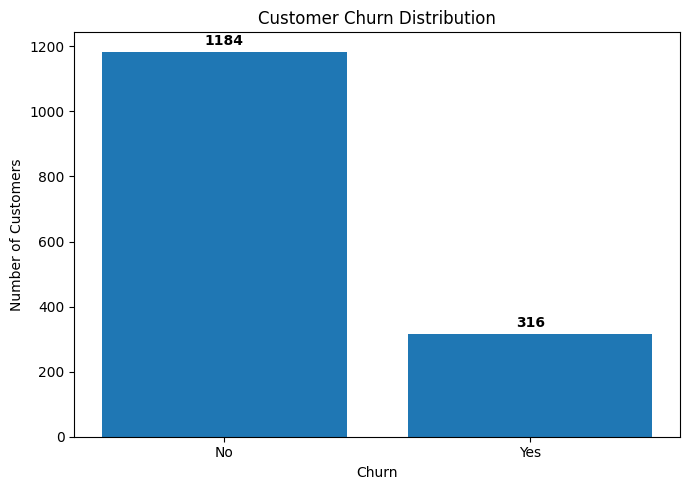

In [6]:
import matplotlib.pyplot as plt

# Churn Distribution
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Display values on bars
for i, value in enumerate(churn_counts.values):
    plt.text(
        i,
        value + 20,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

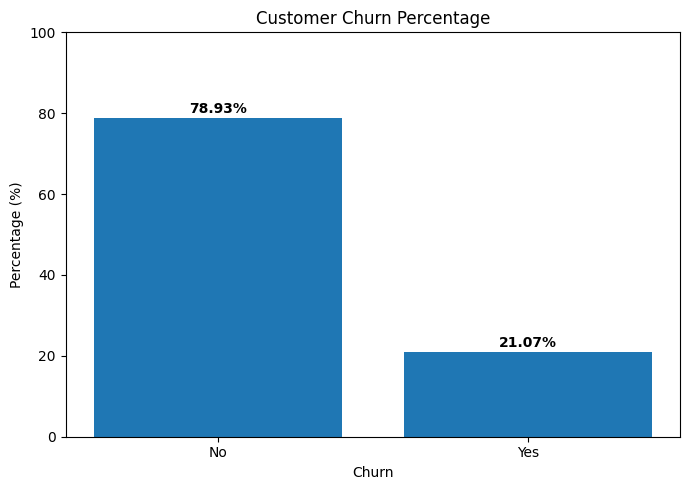

In [7]:
# Churn Percentage Visualization

churn_percentage = df["Churn"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

plt.bar(
    churn_percentage.index,
    churn_percentage.values
)

plt.title("Customer Churn Percentage")
plt.xlabel("Churn")
plt.ylabel("Percentage (%)")

for i, value in enumerate(churn_percentage.values):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

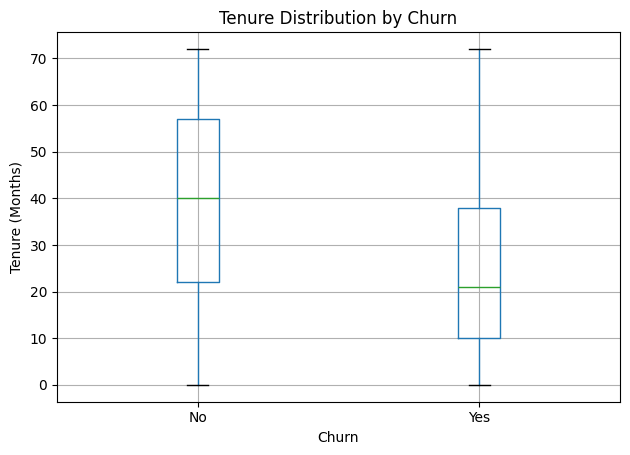

In [8]:
# Step 8.1: Tenure vs Churn

plt.figure(figsize=(8, 5))

df.boxplot(
    column="Tenure",
    by="Churn"
)

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

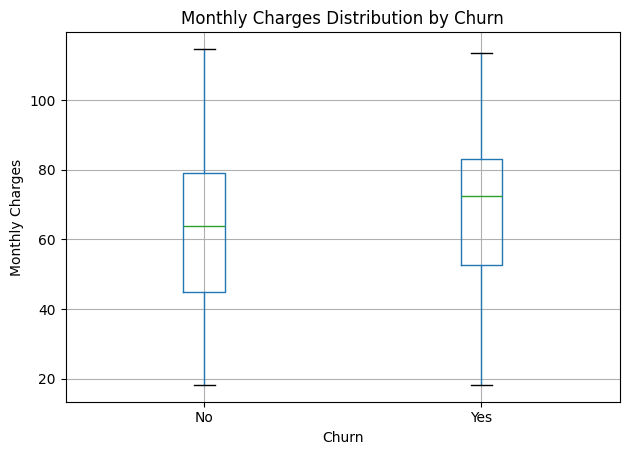

In [9]:
# Step 8.2: Monthly Charges vs Churn

plt.figure(figsize=(8, 5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

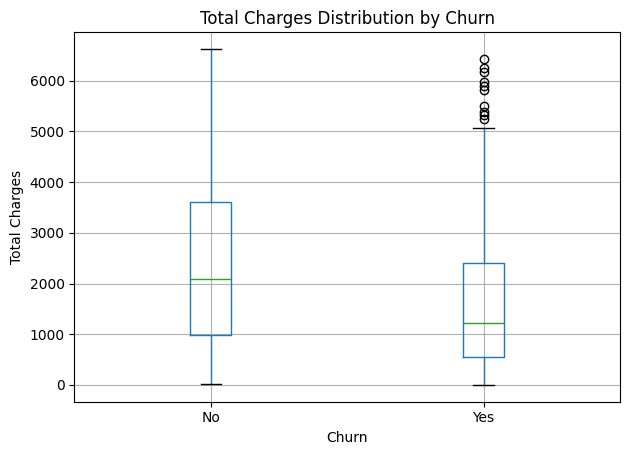

In [10]:
# Step 8.3: Total Charges vs Churn

plt.figure(figsize=(8, 5))

df.boxplot(
    column="TotalCharges",
    by="Churn"
)

plt.title("Total Charges Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

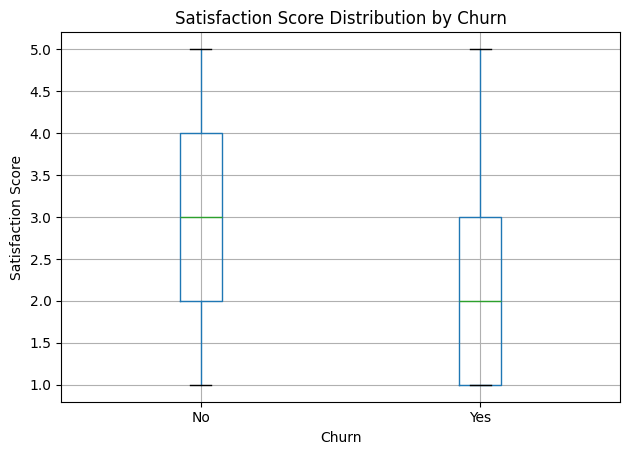

In [11]:
# Step 8.4: Satisfaction Score vs Churn

plt.figure(figsize=(8, 5))

df.boxplot(
    column="SatisfactionScore",
    by="Churn"
)

plt.title("Satisfaction Score Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Satisfaction Score")

plt.tight_layout()
plt.show()

In [12]:
# Step 8.5: Contract vs Churn

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("Contract vs Churn Percentage:")
display(contract_churn.round(2))

Contract vs Churn Percentage:


Churn,No,Yes
Contract,,
Month-to-month,70.48,29.52
One year,84.30,15.70
Two year,94.14,5.86


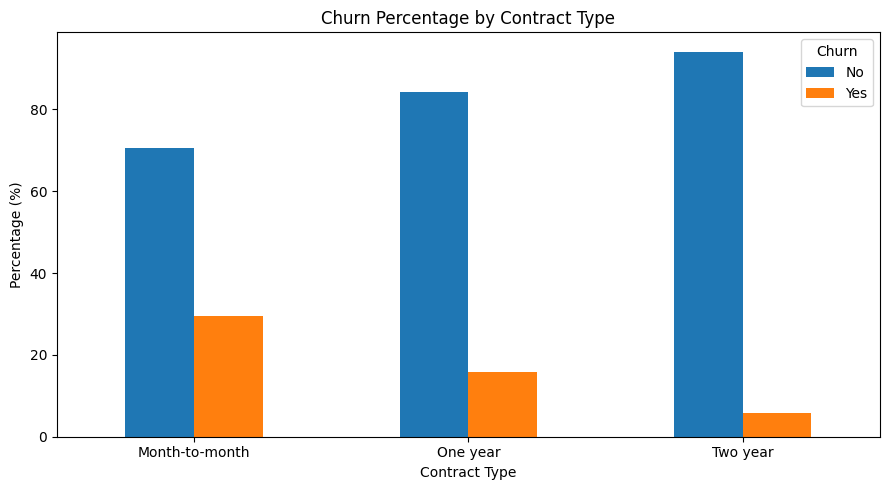

In [13]:
# Contract vs Churn Visualization

contract_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [14]:
# Step 8.6: Internet Service vs Churn

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("Internet Service vs Churn Percentage:")
display(internet_churn.round(2))

Internet Service vs Churn Percentage:


Churn,No,Yes
InternetService,,
DSL,81.66,18.34
Fiber optic,73.97,26.03
No,85.57,14.43


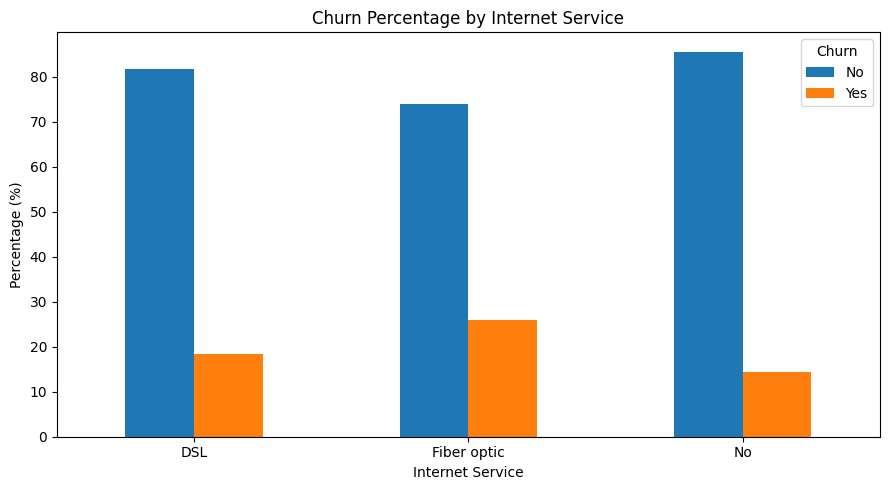

In [15]:
# Internet Service vs Churn Visualization

internet_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Percentage by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [16]:
# ============================================
# STEP 9: FEATURE ENGINEERING
# ============================================

# Create Tenure Groups
df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["New", "Short-term", "Medium-term", "Long-term"]
)

# Service columns
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Count active services
df["TotalServices"] = (
    df[service_columns]
    .apply(lambda row: (row == "Yes").sum(), axis=1)
)

# Display new features
print("New Features Created:")
print(df[["Tenure", "TenureGroup", "TotalServices"]].head(10))

New Features Created:
   Tenure  TenureGroup  TotalServices
0      29  Medium-term              4
1      35  Medium-term              2
2      66    Long-term              3
3      48  Medium-term              3
4      54    Long-term              0
5      55    Long-term              3
6      67    Long-term              2
7      43  Medium-term              0
8      30  Medium-term              0
9      57    Long-term              1


In [17]:
print("Tenure Group Distribution:")
print(df["TenureGroup"].value_counts())

Tenure Group Distribution:
TenureGroup
Long-term      492
Medium-term    490
New            265
Short-term     253
Name: count, dtype: int64


In [18]:
print("\nTotal Services Distribution:")
print(df["TotalServices"].value_counts().sort_index())


Total Services Distribution:
TotalServices
0    354
1    240
2    392
3    298
4    169
5     43
6      4
Name: count, dtype: int64


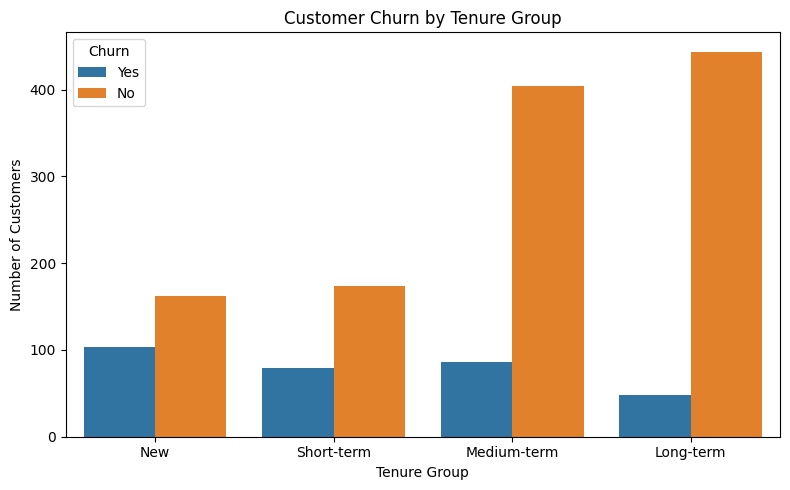

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
# Convert target variable into binary format

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Churn Value Counts:")
print(df["Churn"].value_counts())

print("\nChurn Data Type:")
print(df["Churn"].dtype)

Churn Value Counts:
Churn
0    1184
1     316
Name: count, dtype: int64

Churn Data Type:
int64


In [23]:
# Remove CustomerID because it is only an identifier

df = df.drop(columns=["CustomerID"])

print("Dataset Shape:", df.shape)
print("\nRemaining Columns:")
print(df.columns.tolist())

Dataset Shape: (1500, 22)

Remaining Columns:
['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'SatisfactionScore', 'Churn', 'TenureGroup', 'TotalServices']


In [24]:
# Separate features and target

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Features Shape: (1500, 21)
Target Shape: (1500,)

Target Distribution:
Churn
0    1184
1     316
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Data Shape: (1200, 21)
Testing Data Shape: (300, 21)

Training Target Distribution:
Churn
0    947
1    253
Name: count, dtype: int64

Testing Target Distribution:
Churn
0    237
1     63
Name: count, dtype: int64


In [26]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nNumber of Numerical Features:", len(numerical_features))

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:", len(categorical_features))

Numerical Features:
['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'SatisfactionScore', 'TotalServices']

Number of Numerical Features: 6

Categorical Features:
['Gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Number of Categorical Features: 15


In [27]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [28]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed Training Data Shape:", X_train_processed.shape)
print("Processed Testing Data Shape:", X_test_processed.shape)

Processed Training Data Shape: (1200, 48)
Processed Testing Data Shape: (300, 48)


In [29]:
# Import classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Initialize models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    )
}

print("Models created successfully!")

Models created successfully!


In [30]:
# Train all models

trained_models = {}

for name, model in models.items():
    
    model.fit(X_train_processed, y_train)
    trained_models[name] = model
    
    print(f"{name} trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


In [31]:
# Model Evaluation

results = []

for name, model in trained_models.items():
    
    y_pred = model.predict(X_test_processed)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

print("Model Performance Comparison:")
display(results_df)

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.733333,0.422018,0.730159,0.534884
1,Decision Tree,0.700000,0.263158,0.238095,0.250000
2,Random Forest,0.796667,0.545455,0.190476,0.282353


In [32]:
for name, model in trained_models.items():
    
    y_pred = model.predict(X_test_processed)
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    ))

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81       237
       Churn       0.42      0.73      0.53        63

    accuracy                           0.73       300
   macro avg       0.67      0.73      0.67       300
weighted avg       0.81      0.73      0.75       300

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.80      0.82      0.81       237
       Churn       0.26      0.24      0.25        63

    accuracy                           0.70       300
   macro avg       0.53      0.53      0.53       300
weighted avg       0.69      0.70      0.69       300

Random Forest
              precision    recall  f1-score   support

    No Churn       0.82      0.96      0.88       237
       Churn       0.55      0.19      0.28        63

    accuracy                           0.80       300
   macro avg       0.68      0.57      0.58       300
weighted avg       0.76   

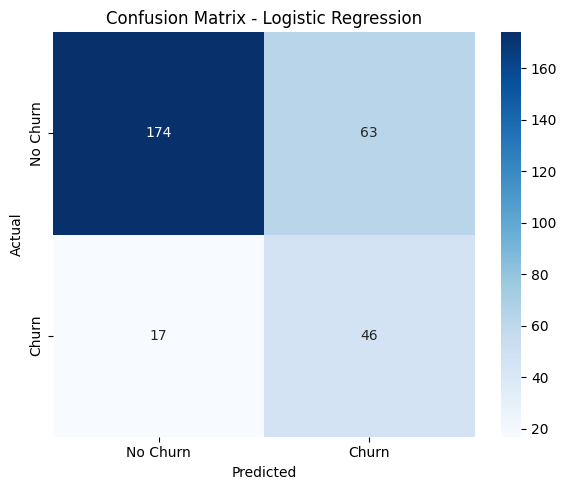

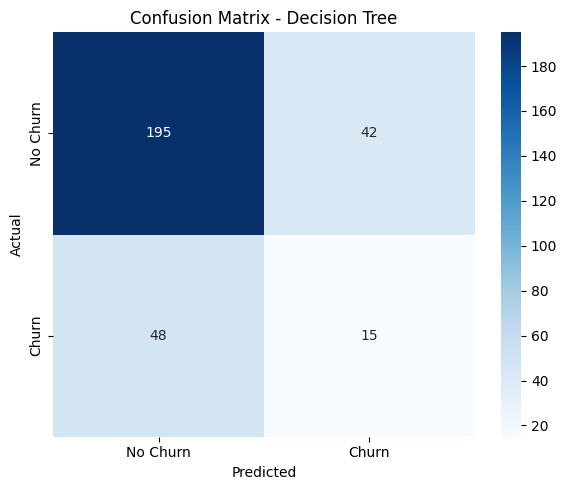

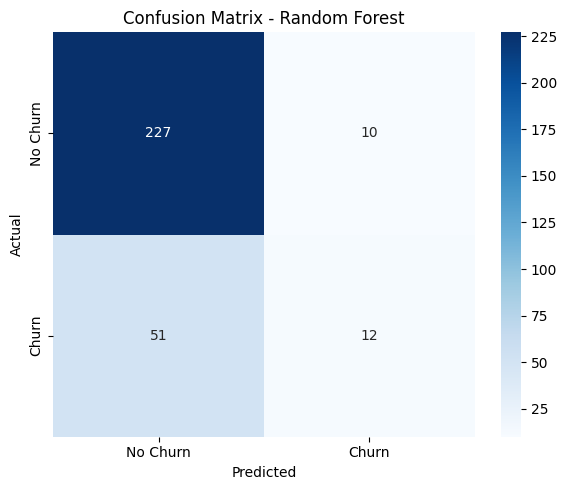

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in trained_models.items():
    
    y_pred = model.predict(X_test_processed)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.tight_layout()
    plt.show()

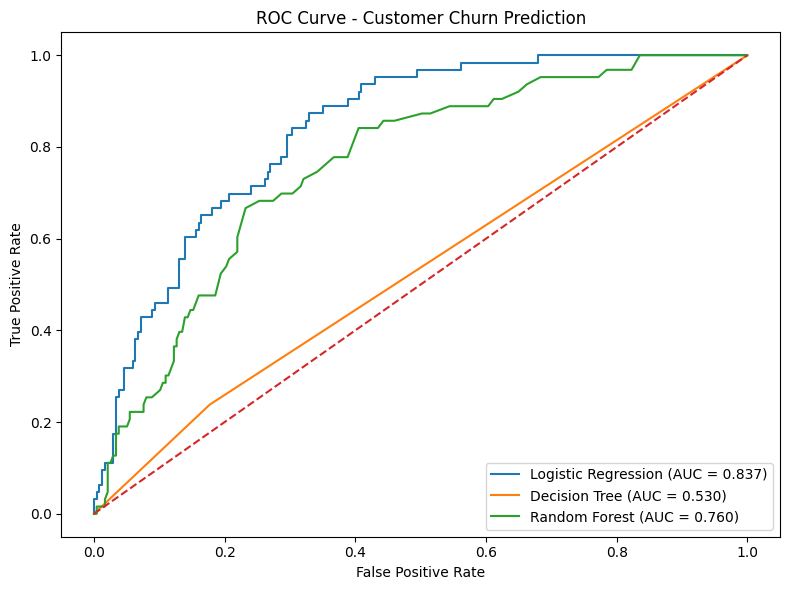

In [34]:
from sklearn.metrics import roc_auc_score, roc_curve

plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve - Customer Churn Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression for tuning

logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# Hyperparameter grid

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

# Grid Search

grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 0.1, 'solver': 'liblinear'}

Best Cross-Validation F1 Score:
0.522933470670783


In [36]:
# Best Logistic Regression Model

best_logistic_model = grid_search.best_estimator_

# Predictions

y_pred_tuned = best_logistic_model.predict(X_test_processed)

# Classification Report

print("Tuned Logistic Regression Performance")
print("=" * 60)

print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["No Churn", "Churn"]
))

Tuned Logistic Regression Performance
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81       237
       Churn       0.41      0.71      0.52        63

    accuracy                           0.73       300
   macro avg       0.66      0.72      0.67       300
weighted avg       0.80      0.73      0.75       300



In [37]:
from sklearn.metrics import roc_auc_score

y_prob_tuned = best_logistic_model.predict_proba(
    X_test_processed
)[:, 1]

tuned_auc = roc_auc_score(
    y_test,
    y_prob_tuned
)

print("Tuned Logistic Regression ROC-AUC:", round(tuned_auc, 3))

Tuned Logistic Regression ROC-AUC: 0.83


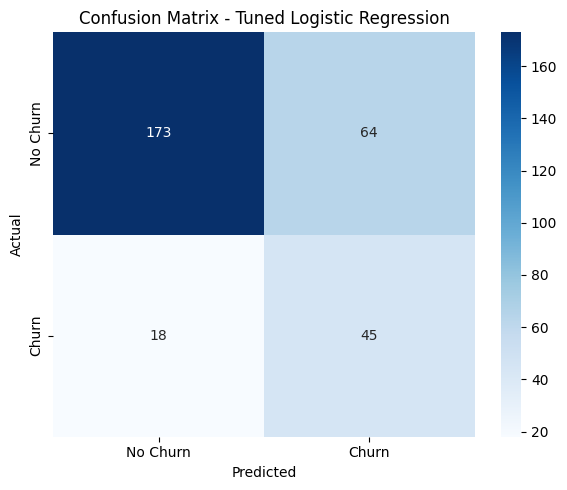

In [38]:
cm = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [39]:
import joblib

# Save final trained model
joblib.dump(
    best_logistic_model,
    "customer_churn_model.pkl"
)

# Save preprocessing pipeline
joblib.dump(
    preprocessor,
    "customer_churn_preprocessor.pkl"
)

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [40]:
import os

print("Model exists:",
      os.path.exists("customer_churn_model.pkl"))

print("Preprocessor exists:",
      os.path.exists("customer_churn_preprocessor.pkl"))

Model exists: True
Preprocessor exists: True


In [41]:
# Load saved model and preprocessor

loaded_model = joblib.load(
    "customer_churn_model.pkl"
)

loaded_preprocessor = joblib.load(
    "customer_churn_preprocessor.pkl"
)

print("Saved model loaded successfully!")
print("Saved preprocessor loaded successfully!")

Saved model loaded successfully!
Saved preprocessor loaded successfully!


In [42]:
# Test prediction using loaded model

sample_customer = X_test.iloc[[0]]

sample_processed = loaded_preprocessor.transform(
    sample_customer
)

prediction = loaded_model.predict(
    sample_processed
)

probability = loaded_model.predict_proba(
    sample_processed
)[0][1]

print("Predicted Churn:", prediction[0])
print("Churn Probability:", round(probability * 100, 2), "%")

Predicted Churn: 0
Churn Probability: 19.42 %


In [43]:
print("Final Model:", type(loaded_model).__name__)
print("Final Preprocessor:", type(loaded_preprocessor).__name__)

print("\nSample Prediction")
print("-------------------------")
print("Predicted Churn:", "Yes" if prediction[0] == 1 else "No")
print("Churn Probability:", round(probability * 100, 2), "%")
print("Retention Probability:", round((1 - probability) * 100, 2), "%")

Final Model: LogisticRegression
Final Preprocessor: ColumnTransformer

Sample Prediction
-------------------------
Predicted Churn: No
Churn Probability: 19.42 %
Retention Probability: 80.58 %
